In [1]:
# 1️⃣  Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_recall_curve, auc,
                             classification_report, confusion_matrix)

from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import shap


In [2]:
# 2️⃣  Carga de datos , se mantiene CustomerId separado , crea splits Train , Hold-out 
df = (pd.read_csv("Customer-Churn-Records.csv")
        .drop(columns=['RowNumber', 'Surname']))

customer_ids = df['CustomerId']          # <--para reporte posterior
y = df['Exited']
X = df.drop(columns=['Exited', 'CustomerId','Complain'])   # <-- elimina de predictores

X_train, X_hold, y_train, y_hold, id_train, id_hold = train_test_split(
    X, y, customer_ids,            # mentiene IDs alineados
    test_size=0.20, stratify=y, random_state=42
)

print(f"Train: {X_train.shape},  Hold‑out: {X_hold.shape}")



Train: (8000, 13),  Hold‑out: (2000, 13)


In [5]:
# 3️⃣  grupos de columnas 

num_cols   = ['EstimatedSalary', 'Point Earned', 'Balance',
              'Tenure', 'Age', 'CreditScore']

disc_cols  = ['Satisfaction Score', 'NumOfProducts']        # escalar

bin_cols   = ['HasCrCard', 'IsActiveMember']    # no escalar

cat_cols   = ['Geography', 'Gender', 'Card Type']           # one‑hot




In [7]:
# 4️⃣  Pipeline, pre procesador 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

preproc = ColumnTransformer([
    ('num',  StandardScaler(),                    num_cols + disc_cols), # escalado de numericas no binarias
    ('cat',  OneHotEncoder(drop='first',
                           sparse_output=False,
                           handle_unknown='ignore'),
             cat_cols), 
    ('bin',  'passthrough',                       bin_cols)   # one-hot sin tocar las binarias 0/1
])

pipe = ImbPipeline([
    ('prep',  preproc),
    ('smote', SMOTE(random_state=42)),
    ('rf',    RandomForestClassifier(n_estimators=100,
                                     random_state=42))
])

print("✅  Pipeline OK.")



✅  Pipeline OK.


### Maximiza F1

In [9]:
# 5️⃣  Cross‑validation para encontrar threshold optimo que maximice F1

cv = StratifiedKFold(5, shuffle=True, random_state=42)
thr_list = []

for fold, (tr, val) in enumerate(cv.split(X_train, y_train), 1):
    pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
    proba = pipe.predict_proba(X_train.iloc[val])[:, 1]

    prec, rec, ths = precision_recall_curve(y_train.iloc[val], proba)
    f1   = 2 * prec * rec / (prec + rec + 1e-6)
    best_thr = ths[np.argmax(f1[:-1])]
    thr_list.append(best_thr)

    print(f"Fold {fold}: best F1‑threshold = {best_thr:.3f}")

opt_thr = float(np.mean(thr_list))
print(f"\n🔑  Optimo threshold = {opt_thr:.4f}")


Fold 1: best F1‑threshold = 0.450
Fold 2: best F1‑threshold = 0.490
Fold 3: best F1‑threshold = 0.370
Fold 4: best F1‑threshold = 0.380
Fold 5: best F1‑threshold = 0.350

🔑  Optimo threshold = 0.4080


### Maximiza Recall

In [10]:
# 5️⃣  Cross‑validation para encontrar threshold que maximiza Recall
cv = StratifiedKFold(5, shuffle=True, random_state=42)
thr_list = []

for fold, (tr, val) in enumerate(cv.split(X_train, y_train), 1):
    pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
    proba = pipe.predict_proba(X_train.iloc[val])[:, 1]

    prec, rec, ths = precision_recall_curve(y_train.iloc[val], proba)
    ths = np.append(ths, 1.0)  # alinear tamaño

    # DataFrame de métricas
    df_metrics = pd.DataFrame({
        'Threshold': ths,
        'Precision': prec,
        'Recall':    rec
    })

    # 🔍 Filtrar: solo thresholds con cierta precisión mínima (ajústalo si quieres)
    df_metrics = df_metrics[df_metrics['Precision'] >= 0.30]

    # Seleccionar el threshold con mejor Recall dentro del filtro
    best_thr = df_metrics.loc[df_metrics['Recall'].idxmax(), 'Threshold']
    thr_list.append(best_thr)

    print(f"Fold {fold}: best Recall‑threshold = {best_thr:.3f}")

# 🔑 Umbral promedio
opt_thr = float(np.mean(thr_list))
print(f"\n🔑  Threshold optimizado para Recall = {opt_thr:.4f}")


Fold 1: best Recall‑threshold = 0.120
Fold 2: best Recall‑threshold = 0.130
Fold 3: best Recall‑threshold = 0.120
Fold 4: best Recall‑threshold = 0.130
Fold 5: best Recall‑threshold = 0.120

🔑  Threshold optimizado para Recall = 0.1240


In [12]:
print(opt_thr)

0.124


              precision    recall  f1-score   support

           0       0.96      0.47      0.64      1592
           1       0.31      0.92      0.47       408

    accuracy                           0.57      2000
   macro avg       0.64      0.70      0.55      2000
weighted avg       0.83      0.57      0.60      2000



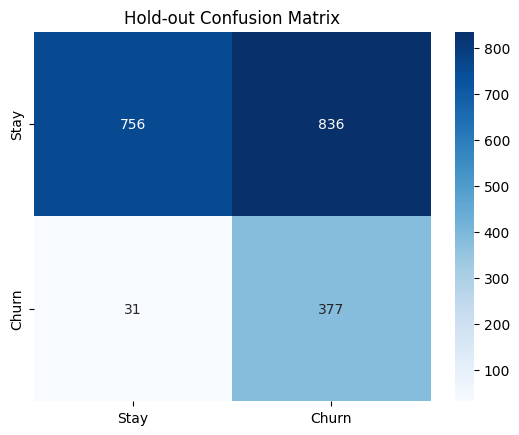

In [14]:
# 6️⃣  Final training + hold‑out evaluation
pipe.fit(X_train, y_train)
proba_hold = pipe.predict_proba(X_hold)[:, 1]
pred_hold  = (proba_hold >= opt_thr).astype(int)

print(classification_report(y_hold, pred_hold))

cm = confusion_matrix(y_hold, pred_hold)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
plt.title("Hold‑out Confusion Matrix")
plt.show()


100%|===================| 3990/4000 [04:26<00:00]        

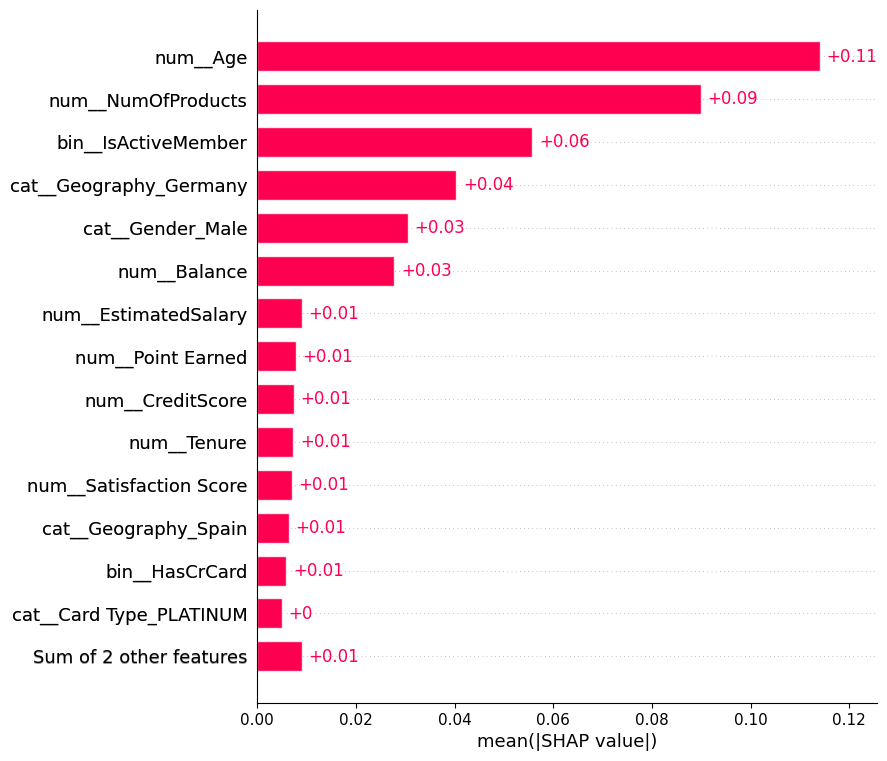

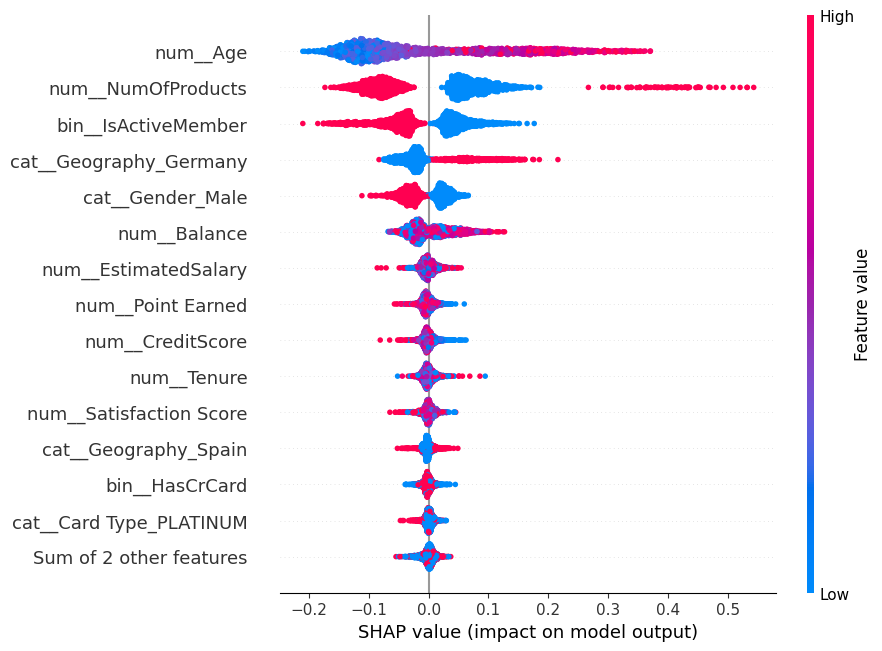

In [16]:
# 7️⃣  SHAP global & local explanations (probability space)
X_hold_trans = pipe['prep'].transform(X_hold)

explainer = shap.Explainer(pipe['rf'],
                           X_hold_trans,
                           feature_names=pipe['prep'].get_feature_names_out())

shap_vals = explainer(X_hold_trans, check_additivity=False)   # <- key change

# Global importance
shap.plots.bar(shap_vals[:, :, 1], max_display=15)
shap.plots.beeswarm(shap_vals[:, :, 1], max_display=15)

# Optional: force plot for a single customer
# idx = 0
# shap.initjs()
# shap.plots.force(shap_vals[idx, :, 1],
#                  feature_names=explainer.feature_names,
#                  matplotlib=True)



El siguiente sirvió para descubrir que Complain es casi siempre una variable que precede a churn , asi que será eliminada.

In [32]:
# 🔍  Leakage‑scan on raw dataset (before dropping any columns)
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency

def leakage_scan(df, target_col='Exited',
                 pearson_thr=0.60, auc_thr=0.95, mi_thr=0.10):
    """
    Returns a DataFrame of features that exceed any leakage‑like threshold.
    - pearson_thr: |corr| threshold for numeric features
    - auc_thr    : AUC threshold for any feature (near‑perfect predictor)
    - mi_thr     : Mutual information threshold
    """
    y = df[target_col]
    X = df.drop(columns=[target_col])

    alerts = []

    # 1) Pearson for purely numeric cols
    num_df = X.select_dtypes(include=np.number)
    if not num_df.empty:
        num_corr = num_df.corrwith(y).abs()
        alerts += [(c, f"|r|={v:.3f}") for c, v in num_corr.items() if v > pearson_thr]

    # 2) AUC for every column (numeric or categorical)
    for col in X.columns:
        if X[col].nunique() < 2:             # constant
            continue
        vec = (pd.get_dummies(X[col], drop_first=True)
               if X[col].dtype == 'object' or X[col].dtype.name == 'category'
               else X[[col]])
        try:
            auc = roc_auc_score(y, vec.sum(axis=1))
            if auc > auc_thr or auc < 1 - auc_thr:
                alerts.append((col, f"AUC={auc:.3f}"))
        except ValueError:
            pass  # occurs if y has only one class – ignore

    # 3) Mutual information on one‑hot encoded matrix
    X_oh = pd.get_dummies(X, drop_first=True)
    mi = mutual_info_classif(X_oh, y, discrete_features='auto', random_state=42)
    alerts += [(c, f"MI={m:.3f}") for c, m in zip(X_oh.columns, mi) if m > mi_thr]

    return (pd.DataFrame(alerts, columns=['Feature', 'Flag'])
              .drop_duplicates()
              .sort_values('Feature')
              .reset_index(drop=True))

# ---- run the leak detector ----
leakage_warnings = leakage_scan(df)     # uses original dataset
display(leakage_warnings)


,Feature,Flag
0,Complain,|r|=0.996
1,Complain,AUC=0.998
2,Complain,MI=0.496


In [21]:
 df['Exited'].value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [18]:
def clasificar_riesgo(row):
    if row['Exited'] == 1:
        return 'Churn'  # detectado o no, churn ocurrió
    elif row['Churn_Pred'] == 1:
        return 'Rescatable'
    else:
        return 'Bajo Riesgo'

In [22]:
# --- 9️⃣  Exportar hold‑out enriquecido ----------------------

import pandas as pd


df_original = df.copy()

# 1) Partimos de X_hold, y_hold y df_original
hold_df = X_hold.copy()

# 2) Recupero CustomerId y Exited del df_original
hold_df['CustomerId'] = df_original.loc[X_hold.index, 'CustomerId']
hold_df['Exited']     = y_hold.values

# 3) Calculo probabilidad y predicción
hold_df['Churn_Prob'] = pipe.predict_proba(X_hold)[:, 1]
hold_df['Churn_Pred'] = (hold_df['Churn_Prob'] >= opt_thr).astype(int)

# 4) Defino nivel de riesgo (ajusta los bins si lo prefieres)
#hold_df['Risk_Level'] = pd.cut(
#    hold_df['Churn_Prob'],
#    bins=[0.0, 0.25, 0.50, 1.0],
#    labels=['LOW', 'MEDIUM', 'HIGH'],
#    include_lowest=True
#)


hold_df['Risk_Level'] = hold_df.apply(clasificar_riesgo, axis=1)


# 5) Reordeno columnas (opcional) para tener primero IDs y target
cols = ['CustomerId', 'Exited'] + \
       [c for c in hold_df.columns if c not in ('CustomerId','Exited','Churn_Prob','Churn_Pred','Risk_Level')] + \
       ['Churn_Prob','Churn_Pred','Risk_Level']
hold_df = hold_df[cols]

# 6) Guardo a CSV
file_path = "churn_holdout_enriched.csv"
hold_df.to_csv(file_path, index=False, encoding='utf-8')
print(f"✅ Archivo guardado en: {file_path}")
print(f"→ Filas: {hold_df.shape[0]}, Columnas: {hold_df.shape[1]}")


✅ Archivo guardado en: churn_holdout_enriched.csv
→ Filas: 2000, Columnas: 18


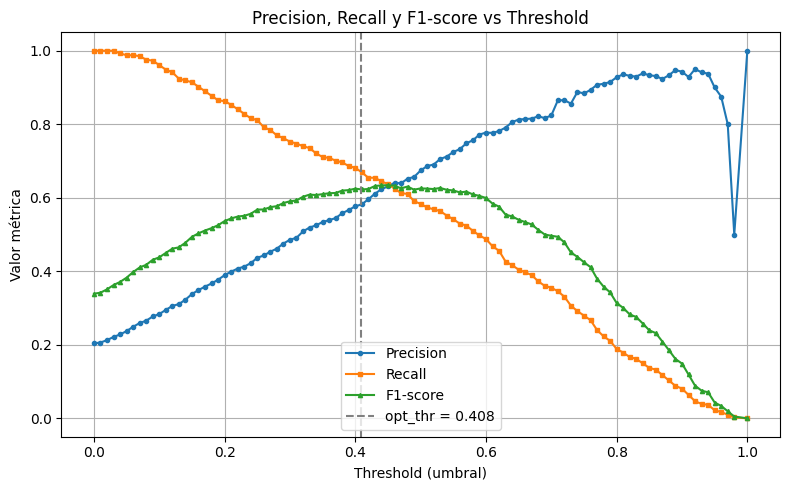

In [29]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣  Calcula métricas en distintos thresholds
prec, rec, ths = precision_recall_curve(y_hold, pipe.predict_proba(X_hold)[:, 1])
f1 = 2 * (prec * rec) / (prec + rec + 1e-6)

# Ajustar el tamaño del vector thresholds para que coincida
ths = np.append(ths, 1.0)

# 2️⃣  Visualiza todo
plt.figure(figsize=(8, 5))
plt.plot(ths, prec, label='Precision', marker='o', markersize=3)
plt.plot(ths, rec,  label='Recall',    marker='s', markersize=3)
plt.plot(ths, f1,   label='F1-score',  marker='^', markersize=3)

plt.axvline(opt_thr, color='gray', linestyle='--', label=f'opt_thr = {opt_thr:.3f}')
plt.xlabel("Threshold (umbral)")
plt.ylabel("Valor métrica")
plt.title("Precision, Recall y F1-score vs Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
